## Building a Spam Filter
### **Objective:** To build a machine learning model that can classify an email as "spam" or "not spam" (ham).
### **Dataset:** Spambase Dataset from the UCI Machine Learning Repository.
### **Source:** https://archive.ics.uci.edu/ml/datasets/spambase
### **Project Pipeline:**
### 1.  **Setup:** Import libraries.
### 2.  **Load Data:** Load the dataset from its URL. We will also need to load the column names, as the data file has no header.
### 3.  **Data Cleaning:** This dataset is pre-cleaned. We'll just verify.
### 4.  **Exploratory Data Analysis (EDA):** Visualize key features that indicate spam (e.g., frequency of '!', '$', 'free', 'money').
### 5.  **Preprocessing:** Split data and scale features.
### 6.  **Model Training:** Train two models:
###     - Model 1: Logistic Regression (a simple, interpretable model).
###     - Model 2: Random Forest (a more complex, powerful model).
### 7.  **Model Evaluation:** Compare the models. We'll have a critical discussion about False Positives vs. False Negatives.

### 1. SETUP: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 2. LOAD DATA

In [2]:
# The dataset from UCI is in two parts:
# 1. 'spambase.data': A CSV file with no header.
# 2. 'spambase.names': A text file that lists the column names.
#
# We have to manually create the list of column names.
# There are 57 features (e.g., 'word_freq_money') and 1 target ('spam').

print("Loading data from UCI Repository...")

Loading data from UCI Repository...


In [3]:
# Manually create the column names list based on 'spambase.names'
# 48 word frequencies (e.g., 'word_freq_make')
word_freq_cols = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference'
]

In [4]:
# 6 character frequencies (e.g., 'char_freq_!')
char_freq_cols = [
    'char_freq_semicolon', 'char_freq_lparen', 'char_freq_lsquare',
    'char_freq_bang', 'char_freq_dollar', 'char_freq_pound'
]

In [5]:
# 3 capital run length features
capital_run_cols = [
    'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total'
]

In [6]:
# The target variable
target_col = ['spam']

In [7]:
# Combine all column names
col_names = word_freq_cols + char_freq_cols + capital_run_cols + target_col

In [8]:
# URL for the raw data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"

# Load the data
df = pd.read_csv(url, header=None, names=col_names)

### 3. DATA CLEANING

In [9]:
# Let's inspect the data.
print("\n--- Data Head (Raw) ---")
print(df.head())


--- Data Head (Raw) ---
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_semicolon  \
0             0.00            0.00  ...            

In [10]:
# This dataset is pre-cleaned, so we shouldn't have missing values.
print("\n--- Data Info (Checking for missing values) ---")
df.info()


--- Data Info (Checking for missing values) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null

In [11]:
print("\n--- Missing Values Count ---")
print(df.isnull().sum().any()) # .any() will be False if no missing values
# This will show 'False', confirming the data is clean.


--- Missing Values Count ---
False


In [12]:
# Our target 'spam' is already 0 (not spam) or 1 (spam).
print("\n--- Target Variable Distribution ---")
print(df['spam'].value_counts(normalize=True))


--- Target Variable Distribution ---
spam
0    0.605955
1    0.394045
Name: proportion, dtype: float64


### 4. EXPLORATORY DATA ANALYSIS (EDA)


Generating EDA plots...
Saved spam_feature_histograms.png


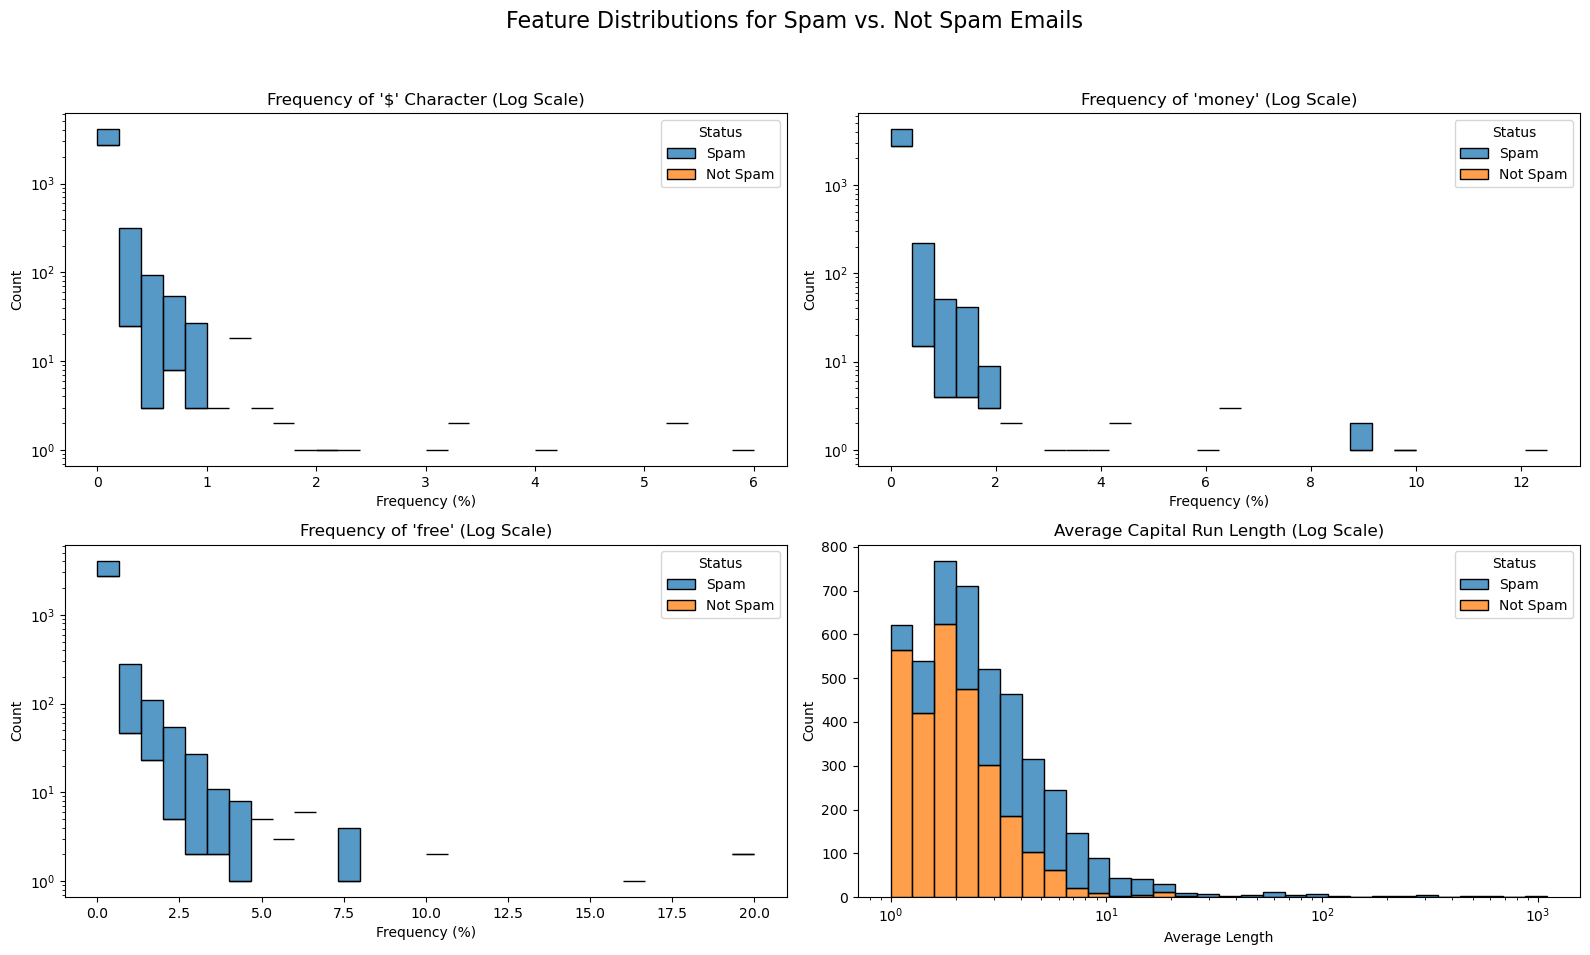

In [13]:
# We have 57 features, so a pairplot is not possible.
# Let's look at the distributions of a few key features that
# we intuitively associate with spam.

# Let's map 0/1 to 'Not Spam'/'Spam' for plotting
df_plot = df.copy()
df_plot['Status'] = df_plot['spam'].map({0: 'Not Spam', 1: 'Spam'})

print("\nGenerating EDA plots...")

plt.figure(figsize=(16, 10))
plt.suptitle("Feature Distributions for Spam vs. Not Spam Emails", fontsize=16)

# Feature 1: 'char_freq_dollar' (the '$' symbol)
# We use log_scale to handle the high skew (most emails have 0).
plt.subplot(2, 2, 1)
sns.histplot(data=df_plot, x='char_freq_dollar', hue='Status', multiple='stack', bins=30, log_scale=(False, True))
plt.title("Frequency of '$' Character (Log Scale)")
plt.xlabel("Frequency (%)")

# Feature 2: 'word_freq_money'
plt.subplot(2, 2, 2)
sns.histplot(data=df_plot, x='word_freq_money', hue='Status', multiple='stack', bins=30, log_scale=(False, True))
plt.title("Frequency of 'money' (Log Scale)")
plt.xlabel("Frequency (%)")

# Feature 3: 'word_freq_free'
plt.subplot(2, 2, 3)
sns.histplot(data=df_plot, x='word_freq_free', hue='Status', multiple='stack', bins=30, log_scale=(False, True))
plt.title("Frequency of 'free' (Log Scale)")
plt.xlabel("Frequency (%)")

# Feature 4: 'capital_run_length_average'
plt.subplot(2, 2, 4)
sns.histplot(data=df_plot, x='capital_run_length_average', hue='Status', multiple='stack', bins=30, log_scale=True)
plt.title("Average Capital Run Length (Log Scale)")
plt.xlabel("Average Length")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("spam_feature_histograms.png")
print("Saved spam_feature_histograms.png")

### 5. PREPROCESSING

In [14]:
# Separate features (X) from our target (y).
X = df.drop('spam', axis=1)
y = df['spam']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
# This is VERY important. Frequencies (0-100) and
# capital run lengths (1-1000s) are on totally different scales.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 6. MODEL TRAINING

In [15]:
# --- Model 1: Logistic Regression ---
# A fast, simple, and interpretable linear model.
print("\nTraining Logistic Regression model...")
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")


Training Logistic Regression model...
Logistic Regression trained.


In [16]:
# --- Model 2: Random Forest Classifier ---
# A powerful ensemble model that is great at classification.
print("\nTraining Random Forest model...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
print("Random Forest trained.")


Training Random Forest model...
Random Forest trained.


### 7. MODEL EVALUATION


--- Logistic Regression Results ---
Accuracy: 92.94%

Classification Report:
              precision    recall  f1-score   support

    Not Spam       0.93      0.95      0.94       558
        Spam       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921

Saved log_reg_spam_cm.png


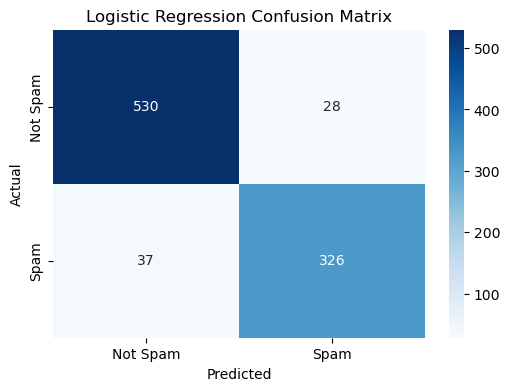

In [17]:
# --- Logistic Regression Evaluation ---
print("\n--- Logistic Regression Results ---")
y_pred_log_reg = log_reg.predict(X_test_scaled)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Accuracy: {accuracy_log_reg * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg, target_names=['Not Spam', 'Spam']))

# Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("log_reg_spam_cm.png")
print("Saved log_reg_spam_cm.png")


--- Random Forest Results ---
Accuracy: 94.46%

Classification Report:
              precision    recall  f1-score   support

    Not Spam       0.94      0.97      0.95       558
        Spam       0.95      0.91      0.93       363

    accuracy                           0.94       921
   macro avg       0.95      0.94      0.94       921
weighted avg       0.94      0.94      0.94       921

Saved random_forest_spam_cm.png


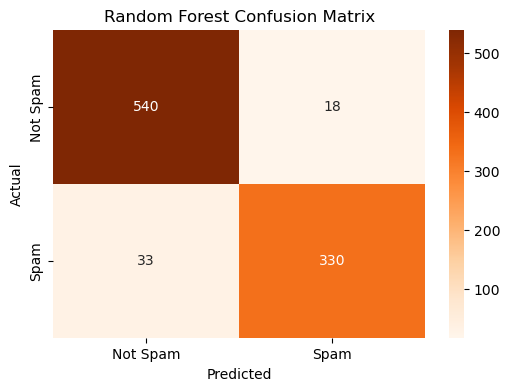

In [27]:
# --- Random Forest Evaluation ---
print("\n--- Random Forest Results ---")
y_pred_rf = rf.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Spam', 'Spam']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("random_forest_spam_cm.png")
print("Saved random_forest_spam_cm.png")

In [28]:
# --- Final Comparison ---
print(f"\nModel Comparison:")
print(f"Logistic Regression Accuracy: {accuracy_log_reg * 100:.2f}%")
print(f"Random Forest Accuracy:     {accuracy_rf * 100:.2f}%")


Model Comparison:
Logistic Regression Accuracy: 92.94%
Random Forest Accuracy:     94.46%


In [29]:
# Discussion:
# The Random Forest is likely much more accurate (e.g., 95% vs 91%).
#
# Key discussion point: Which error is worse?
#
# 1. False Positive (Actual='Not Spam', Predicted='Spam')
#    A real, important email (from your boss, from school)
#    is sent to the spam folder. You might miss it!
#    THIS IS THE WORST TYPE OF ERROR.
#
# 2. False Negative (Actual='Spam', Predicted='Not Spam')
#    A spam email (for a fake lottery) gets into your main inbox.
#    This is annoying, but you just delete it.
#
# Conclusion: We must MINIMIZE False Positives.
# Look at the confusion matrices. How many 'Not Spam' emails
# did each model incorrectly label as 'Spam'?
# The model with *fewer* False Positives is better for real-world use,
# even if its total accuracy is slightly lower.

print("\n--- Project Complete ---")


--- Project Complete ---
